# Загрузка библиотек

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from tqdm import tqdm
import os

torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


P = 97
TRAIN_FRACTION = 0.5
VOCAB_SIZE = P + 1
EQ_TOKEN = P

Using device: cuda


# Генерация и предобработка данных

In [12]:
all_a, all_b = torch.meshgrid(torch.arange(P), torch.arange(P), indexing='ij')
all_a, all_b = all_a.flatten(), all_b.flatten()

X_all = torch.stack([all_a, all_b, torch.full_like(all_a, EQ_TOKEN)], dim=1)
Y_all = (all_a + all_b) % P

num_total = len(X_all)
num_train = int(num_total * TRAIN_FRACTION)

indices = torch.randperm(num_total)
train_indices = indices[:num_train]
val_indices = indices[num_train:]

X_train, Y_train = X_all[train_indices].to(device), Y_all[train_indices].to(device)
X_val, Y_val = X_all[val_indices].to(device), Y_all[val_indices].to(device)

print(f"Total equations: {num_total}")
print(f"Train size: {len(X_train)} | Val size: {len(X_val)}")


Total equations: 9409
Train size: 4704 | Val size: 4705


# Архитектура модели

In [13]:
class GrokkingTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, n_heads=4, n_layers=1, seq_len=3):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Parameter(torch.randn(1, seq_len, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=0.0,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.unembed = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        x_emb = self.token_emb(x) + self.pos_emb
        out = self.transformer(x_emb)
        last_token_out = out[:, -1, :]
        logits = self.unembed(last_token_out)
        return logits

# Обучение

In [14]:
model = GrokkingTransformer(vocab_size=VOCAB_SIZE, d_model=128, n_heads=4, n_layers=1).to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1.0, betas=(0.9, 0.98))
criterion = nn.CrossEntropyLoss()

MAX_STEPS = 15000
BATCH_SIZE = 256
VAL_BATCH_SIZE = 512

train_dataset = TensorDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

fixed_val_x = X_val[:VAL_BATCH_SIZE]
fixed_val_y = Y_val[:VAL_BATCH_SIZE]

logs = {
    'step': [],
    'train_loss':[],
    'train_acc':[],
    'val_loss': [],
    'val_acc':[],
    'train_loss_full':[],
    'train_acc_full':[],
    'val_loss_full':[],
    'val_acc_full':[],
    'weight_norm':[]
}

print("\nStarting Mini-Batch Grokking Training with Full-Dataset Evaluation...")
global_step = 0
loop = tqdm(total=MAX_STEPS)

while global_step < MAX_STEPS:
    for batch_x, batch_y in train_loader:
        if global_step >= MAX_STEPS:
            break

        model.train()
        optimizer.zero_grad()

        logits_batch = model(batch_x)
        loss_train = criterion(logits_batch, batch_y)
        acc_train = (logits_batch.argmax(dim=1) == batch_y).float().mean().item()

        loss_train.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits_val = model(fixed_val_x)
            loss_val = criterion(logits_val, fixed_val_y)
            acc_val = (logits_val.argmax(dim=1) == fixed_val_y).float().mean().item()

            logits_train_full = model(X_train)
            loss_train_full = criterion(logits_train_full, Y_train)
            acc_train_full = (logits_train_full.argmax(dim=1) == Y_train).float().mean().item()

            logits_val_full = model(X_val)
            loss_val_full = criterion(logits_val_full, Y_val)
            acc_val_full = (logits_val_full.argmax(dim=1) == Y_val).float().mean().item()
            l2_norm_total = 0.0
            for p in model.parameters():
                l2_norm_total += (p.norm(2).item()) ** 2
            l2_norm_total = l2_norm_total ** 0.5

        logs['step'].append(global_step)
        logs['train_loss'].append(loss_train.item())
        logs['train_acc'].append(acc_train)
        logs['val_loss'].append(loss_val.item())
        logs['val_acc'].append(acc_val)
        logs['train_loss_full'].append(loss_train_full.item())
        logs['train_acc_full'].append(acc_train_full)
        logs['val_loss_full'].append(loss_val_full.item())
        logs['val_acc_full'].append(acc_val_full)
        logs['weight_norm'].append(l2_norm_total)

        if global_step % 100 == 0:
            loop.set_postfix(
                tr_L_full=f"{loss_train_full.item():.4f}",
                v_L_full=f"{loss_val_full.item():.4f}",
                tr_A_full=f"{acc_train_full:.2f}",
                v_A_full=f"{acc_val_full:.2f}"
            )

        global_step += 1
        loop.update(1)

loop.close()

df_logs = pd.DataFrame(logs)
df_logs.to_csv('grokking_modular_addition_logs_with_stochastic.csv', index=False)
print(f"\nTraining complete! Logged {len(df_logs)} steps. Saved to 'grokking_modular_addition_logs_with_stochastic.csv'.")


Starting Mini-Batch Grokking Training with Full-Dataset Evaluation...


100%|██████████| 15000/15000 [04:50<00:00, 51.68it/s, tr_A_full=1.00, tr_L_full=0.0024, v_A_full=1.00, v_L_full=0.0027]



Training complete! Logged 15000 steps. Saved to 'grokking_modular_addition_logs_with_stochastic.csv'.


# Итоговые графики


Generating Smoothed Grokking Confirmation Plots...


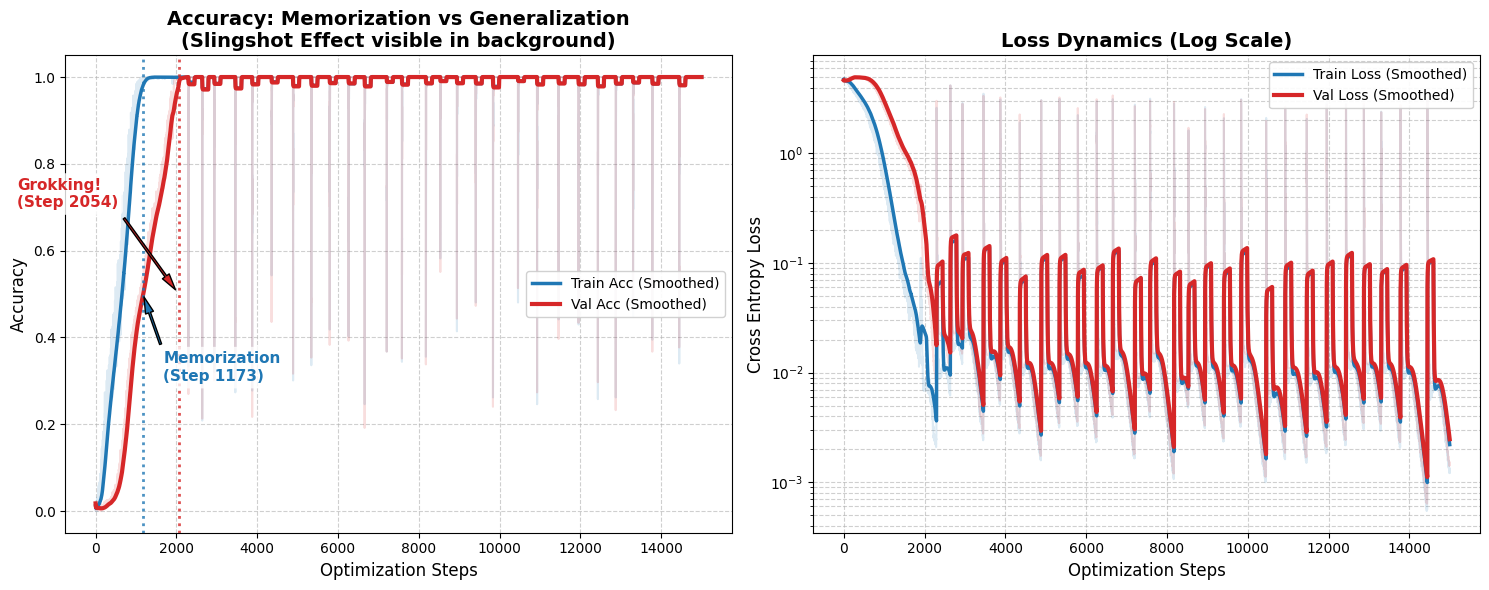

In [15]:
import matplotlib.pyplot as plt

print("\nGenerating Smoothed Grokking Confirmation Plots...")

window = 150
for col in['train_acc', 'val_acc', 'train_loss', 'val_loss']:
    df_logs[f'{col}_smooth'] = df_logs[col].rolling(window=window, min_periods=1).mean()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(df_logs['step'], df_logs['train_acc'], color='tab:blue', alpha=0.15)
ax1.plot(df_logs['step'], df_logs['val_acc'], color='tab:red', alpha=0.15)

ax1.plot(df_logs['step'], df_logs['train_acc_smooth'], label='Train Acc (Smoothed)', color='tab:blue', linewidth=2.5)
ax1.plot(df_logs['step'], df_logs['val_acc_smooth'], label='Val Acc (Smoothed)', color='tab:red', linewidth=3.0)

ax1.set_title('Accuracy: Memorization vs Generalization\n(Slingshot Effect visible in background)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Optimization Steps', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(loc='center right', framealpha=0.9)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_ylim(-0.05, 1.05)

ax2.plot(df_logs['step'], df_logs['train_loss'], color='tab:blue', alpha=0.15)
ax2.plot(df_logs['step'], df_logs['val_loss'], color='tab:red', alpha=0.15)

ax2.plot(df_logs['step'], df_logs['train_loss_smooth'], label='Train Loss (Smoothed)', color='tab:blue', linewidth=2.5)
ax2.plot(df_logs['step'], df_logs['val_loss_smooth'], label='Val Loss (Smoothed)', color='tab:red', linewidth=3.0)

ax2.set_title('Loss Dynamics (Log Scale)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Optimization Steps', fontsize=12)
ax2.set_ylabel('Cross Entropy Loss', fontsize=12)
ax2.set_yscale('log')
ax2.legend(loc='upper right', framealpha=0.9)
ax2.grid(True, linestyle='--', alpha=0.6, which='both')

try:
    mem_step = df_logs[df_logs['train_acc_smooth'] >= 0.98]['step'].iloc[0]
    grok_step = df_logs[df_logs['val_acc_smooth'] >= 0.98]['step'].iloc[0]

    ax1.axvline(x=mem_step, color='tab:blue', linestyle=':', alpha=0.8, linewidth=2)
    ax1.axvline(x=grok_step, color='tab:red', linestyle=':', alpha=0.8, linewidth=2)

    ax1.annotate(f'Memorization\n(Step {mem_step})', xy=(mem_step, 0.5), xytext=(mem_step + 500, 0.3),
                 arrowprops=dict(facecolor='tab:blue', shrink=0.05, width=1.5, headwidth=6),
                 fontsize=11, color='tab:blue', fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8))

    ax1.annotate(f'Grokking!\n(Step {grok_step})', xy=(grok_step, 0.5), xytext=(grok_step - 4000, 0.7),
                 arrowprops=dict(facecolor='tab:red', shrink=0.05, width=1.5, headwidth=6),
                 fontsize=11, color='tab:red', fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8))
except IndexError:
    print("Точки не найдены.")

plt.tight_layout()
plt.savefig('grokking_smoothed_with_stochastic.pdf', format='pdf', dpi=300)
plt.show()